# Market Seams on the WSCC 9-Bus Network

**Teaching companion to _Market Seams in the Western Interconnection_ (Dockery, 2026).**

This notebook builds small, hand-tunable examples on the WSCC / IEEE 9-bus test
system to make the paper's three structural results concrete:

| Section | Paper | What you see |
|---|---|---|
| **1. Shared network & shift factors** | §2.1 | The network $\mathcal N,\mathcal M$ and the shift-factor matrix $SF_{n,m}$ |
| **2. One engine (unified clearing)** | §2.7 | DC power flow, nodal LMPs $\lambda_n$, congestion on constrained paths |
| **3. Two engines — dispatch interference** | §4 (Part 3) | Each engine within its own limits, **combined flow overloads** (eq. 32 vs 33) |
| **4. Two engines — price-taking export** | §2.3, §3 (Part 2) | A's export is a **fixed, price-insensitive** input to B; the **seam dual gap** $\Delta\lambda_n$ |
| **5. Sandbox** | — | Knobs for footprints, costs, ratings, interchange |

All computation lives in [`seams_engine.py`](seams_engine.py): a transparent
PTDF DC-OPF whose objects map one-to-one onto the paper's notation
($SF_{n,m}$, $\lambda^M_n$, $\mu^M_m$, $F^M_m$, the superposition $F^{\text{phys}}=\sum_M F^M$).
Each *engine* optimises only its own resources and loads, enforces limits only on
its own activated constraints, and computes flow only against its own injections —
the cross-engine pieces enter as exogenous schedules.

> **How to use:** every section starts with an `# -- EDIT --` config cell. Change the
> numbers, re-run the section, watch the prices and flows move.

## 0. Setup

In [ ]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


In [1]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from ieee9_network import build_ieee9_network
import seams_engine, nodal_plot
importlib.reload(seams_engine); importlib.reload(nodal_plot)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)
print('ready')

ready

### Master fleet & load tables

The 9-bus system has three generators (a \$20, a \$35, and a \$50 unit) and three
loads. These are the physical primitives; the *market* partition (which bus
belongs to which engine) is chosen later and independently.

```
        (1)gen $20            (3)gen $50
          |                     |
         [4]---[5]load---[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [2]:
# Physical primitives -- the resource stack and loads on the shared network
GEN_FLEET = {
    'gen_slack_0': {'bus': '1', 'cost': 20.0, 'p_nom': 250.0},   # cheap baseload
    'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},   # mid-merit
    'gen_1':       {'bus': '3', 'cost': 50.0, 'p_nom': 270.0},   # peaker
}
LOADS = {'5': 90.0, '7': 100.0, '9': 125.0}

# Circlize sector order: clockwise from 12 o'clock, following the network ring
# so the chord diagram reads in the same spatial order as the topology diagram.
RING_ORDER = ['3', '6', '7', '8', '2', '9', '4', '1', '5']

# Orientation, applied to ALL node + circlize plots so they read alike:
#  - node diagram rotated 180deg  -> bus 3 at the bottom, bus 2 NW, bus 9 at top;
#  - circlize centred on bus 9    -> bus 9 across 12 o'clock, bus 3 near the bottom.
ROTATION_DEG = 180
CENTER_BUS = '9'
COORDS = nodal_plot.rotate_coords(nodal_plot.IEEE9_COORDS, ROTATION_DEG)

def build_network(line_ratings=None):
    # Build the 9-bus PyPSA network, applying any line-rating overrides.
    n = build_ieee9_network(periods=1)
    for ln, mw in (line_ratings or {}).items():
        n.lines.loc[ln, 's_nom'] = float(mw)
    return n

def make_engine(name, buses, activated='all'):
    # Assign every fleet gen and load whose bus is in `buses` to this engine.
    buses = {str(b) for b in buses}
    gens = {g: dict(s) for g, s in GEN_FLEET.items() if str(s['bus']) in buses}
    loads = {b: mw for b, mw in LOADS.items() if b in buses}
    return MarketEngine(name=name, gens=gens, loads=loads, activated_lines=activated)

print('fleet:', {g: (s['bus'], s['cost'], s['p_nom']) for g, s in GEN_FLEET.items()})
print('loads:', LOADS)
print('ring order:', RING_ORDER, '| rotation', ROTATION_DEG, 'deg | centre bus', CENTER_BUS)

fleet:

{'gen_slack_0': ('1', 20.0, 250.0), 'gen_0': ('2', 35.0, 300.0), 'gen_1': ('3', 50.0, 270.0)}

loads:

{'5': 90.0, '7': 100.0, '9': 125.0}

ring order:

['3', '6', '7', '8', '2', '9', '4', '1', '5']

| rotation

180

deg | centre bus

9

## 1. Shared network & shift factors  (§2.1)

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

The shift-factor (PTDF) matrix is a primitive of the **physics**, shared by every
engine. Everything downstream — each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ — is built from this one matrix.

In [3]:
pt = compute_ptdf(build_network(), slack_bus='1')
SF = pd.DataFrame(pt.ptdf,
                  index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)],
                  columns=[f'bus {b}' for b in pt.buses]).round(3)
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
SF

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

,bus 1,bus 2,bus 3,bus 4,bus 5,bus 6,bus 7,bus 8,bus 9
line_0 (1-4),0.0,-1.000,-1.000,-1.0,-1.000,-1.000,-1.000,-1.000,-1.000
line_1 (4-5),0.0,-0.361,-0.615,-0.0,-0.865,-0.615,-0.467,-0.361,-0.125
line_2 (5-6),0.0,-0.361,-0.615,-0.0,0.135,-0.615,-0.467,-0.361,-0.125
line_3 (3-6),0.0,0.000,1.000,-0.0,0.000,0.000,-0.000,0.000,0.000
line_4 (6-7),0.0,-0.361,0.385,0.0,0.135,0.385,-0.467,-0.361,-0.125
line_5 (7-8),0.0,-0.361,0.385,-0.0,0.135,0.385,0.533,-0.361,-0.125
line_6 (8-2),0.0,-1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
line_7 (8-9),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,-0.125
line_8 (9-4),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,0.875


### Line "slipperiness" — the reactance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across it is its **susceptance**
$b_m = 1/x_m$ — a low-reactance line is *slippery* and soaks up a disproportionate
share of any transfer, all else equal. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more slippery), giving a physical
picture of *where power prefers to flow* before any dispatch is chosen. Width is an
**orthogonal channel** to the congestion colour used later: width = slipperiness,
red = binding.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


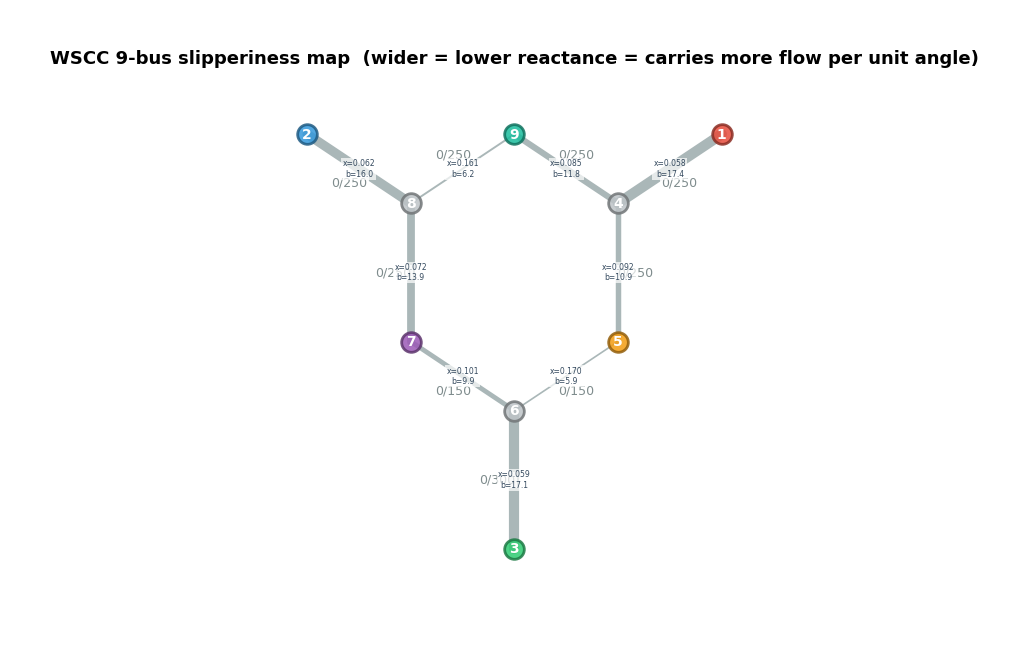

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a reactance map, no flows.
sup = {}
for _g, _s in GEN_FLEET.items():
    sup.setdefault(_s['bus'], []).append(_s)
node_colors = assign_bus_colors(pt.buses, sup, LOADS)

# Pure reactance map: no dispatch annotations, no flows -- width encodes
# slipperiness only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus slipperiness map  (wider = lower reactance = carries more flow per unit angle)',
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. One engine — the unified clearing  (§2.7 counterfactual)

A single optimisation over **all** resources, loads, and constraints. This is the
benchmark the seams problem is measured against: one price per bus, every
transmission limit enforced against the true total flow.

**Edit below:** generator costs, load levels, and line ratings. Tightening a line
creates congestion and pulls the LMPs apart — *price separation on the constrained
path*.

In [5]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_1': 90.0, 'line_5': 90.0}   # squeeze 4-5 and 7-8 -> congestion
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 183.2, 'gen_0': 121.8, 'gen_1': 10.0}

energy price :

20.0

$/MWh

binding lines:

{'line_1': -46.0, 'line_5': 4.5}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,20.0,35.0,50.0,20.0,60.37,50.0,43.85,35.0,25.18


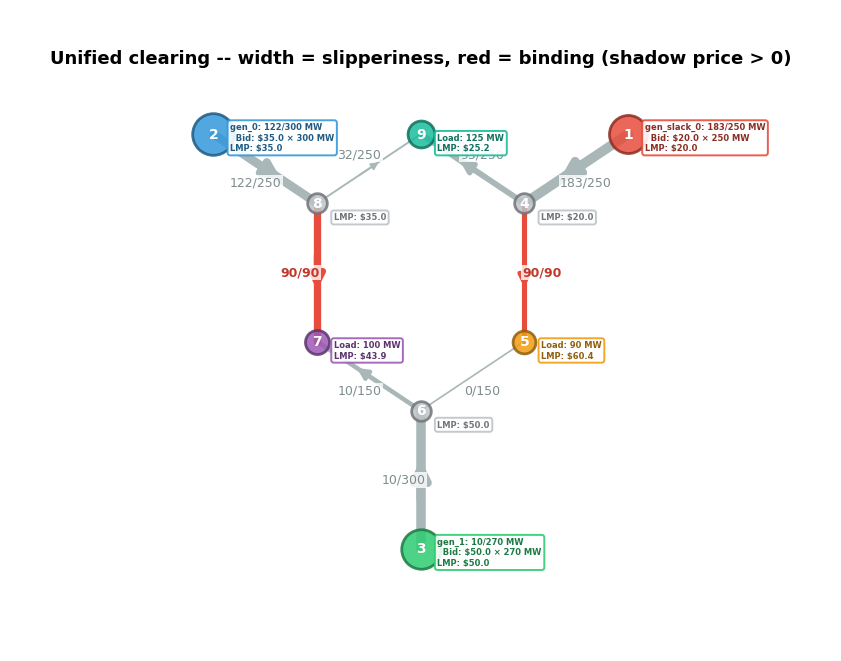

In [6]:
# Topology with DC power flow. Line WIDTH = slipperiness (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = assign_bus_colors(pt.buses, sup, dem)
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    title='Unified clearing -- width = slipperiness, red = binding (shadow price > 0)',
)
plt.show()

### Nodal merit-order + chord view, and the congestion shadow price

The same circlize diagram used in [`inspect_sced_results.ipynb`](inspect_sced_results.ipynb),
built here from the unified DC-OPF. Each sector is a bus: the **left** half is the
merit-order staircase (solid = dispatched, faded = available capacity, dotted line =
marginal cost), the **right** half is the demand bar drawn at **LMP height**, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of eq. (5), and the
exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

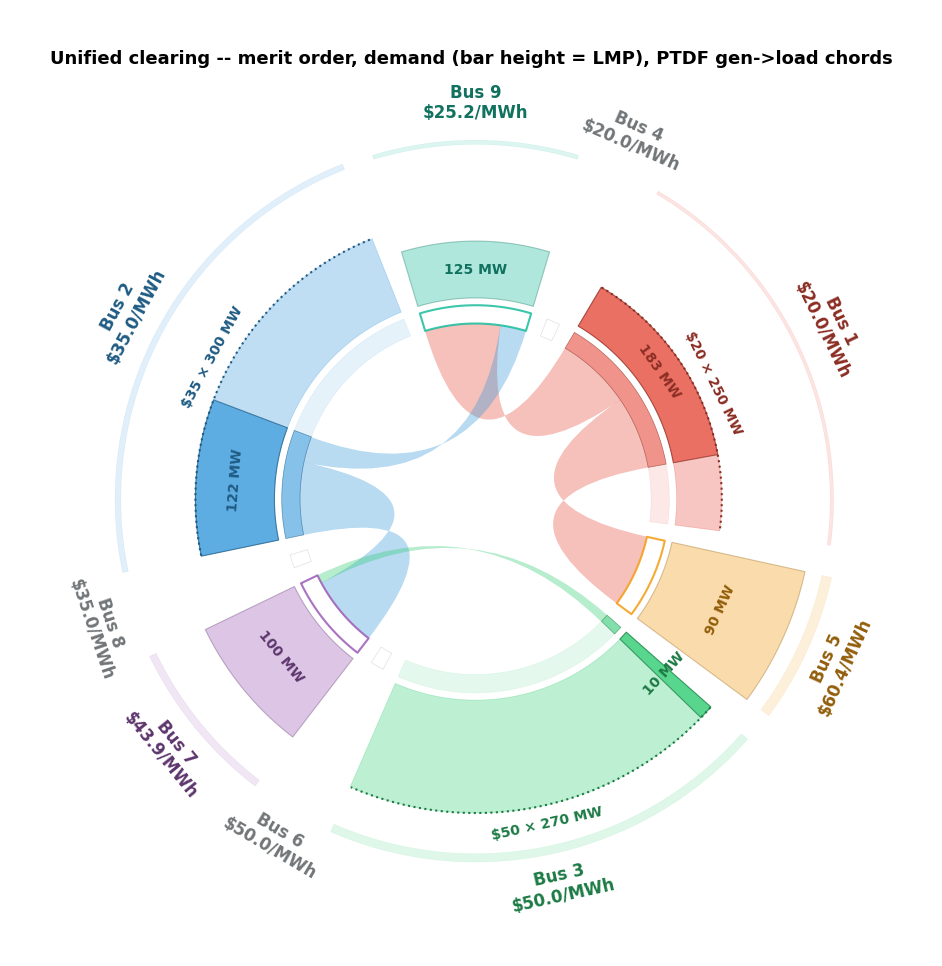

Binding transmission constraints -- congestion shadow price |mu_m| (eq. 5):

  line_1 (4-5): |mu| = $45.98/MWh   (flow +90 MW at the 90 MW limit)

  line_5 (7-8): |mu| = $4.46/MWh   (flow -90 MW at the 90 MW limit)


Settlement by node  (payments to generation vs payments by load):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,20.0,183.2,3664.5,0.0,0.0
2,35.0,121.8,4262.2,0.0,0.0
3,50.0,10.0,500.0,0.0,0.0
4,20.0,0.0,0.0,0.0,0.0
5,60.37,0.0,0.0,90.0,5432.9
6,50.0,0.0,0.0,0.0,0.0
7,43.85,0.0,0.0,100.0,4385.4
8,35.0,0.0,0.0,0.0,0.0
9,25.18,0.0,0.0,125.0,3147.9


...

(equal by the LMP decomposition: the energy component nets to zero because total gen = total load,
 so only the congestion term survives, and it equals mu x flow on each binding line.)


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,183.2,250.0,False,0.0,0.0
line_1,4,5,90.0,90.0,True,45.98,4137.8
line_2,5,6,0.0,150.0,False,0.0,0.0
line_3,3,6,10.0,300.0,False,0.0,0.0
line_4,6,7,10.0,150.0,False,0.0,0.0
line_5,7,8,-90.0,90.0,True,4.46,401.7
line_6,8,2,-121.8,250.0,False,0.0,0.0
line_7,8,9,31.8,250.0,False,0.0,0.0
line_8,9,4,-93.2,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $4,539.5/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [7]:
# Circlize / chord view of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, dem)   # PTDF-traced gen->load chords
gen_mc = {g: spec['cost'] for g, spec in unified.gens.items()}

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    gen_marginal_costs=gen_mc,
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Unified clearing -- merit order, demand (bar height = LMP), PTDF gen->load chords',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m (eq. 5).
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m| (eq. 5):')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# â”€â”€ Settlement accounting: payments by node, subtotals, congestion rent â”€â”€â”€â”€â”€â”€
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * unified.loads.get(b, 0.0), 1)}
     for b in pt.buses]
).set_index('bus')

gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total gen = total load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# â”€â”€ Marginal value of line capacity: shadow price x flow, per line â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# â”€â”€ Export both tables to CSV (overwritten every run) for the Word write-up â”€â”€
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Letter-size composite figure (for the write-up)

The network diagram and the circlize/chord diagram laid out **side by side**,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the chord panel, so nothing is duplicated;
- on each circlize sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a 300-dpi PNG and a vector PDF, overwritten each run.

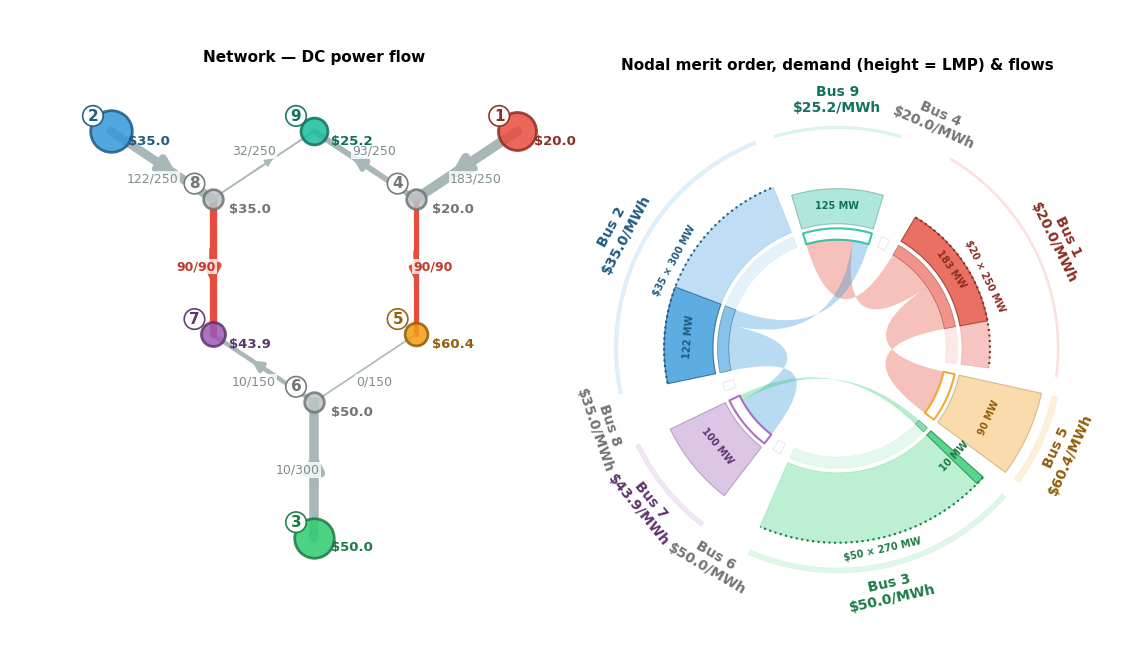

wrote seams_combined_figure.png (300 dpi) and seams_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
    clearing_price=res.energy_price,
    gen_marginal_costs={g: s['cost'] for g, s in unified.gens.items()},
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
)
fig.savefig('seams_combined_figure.png', dpi=300, bbox_inches='tight')
fig.savefig('seams_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote seams_combined_figure.png (300 dpi) and seams_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_1` (4–5) and `line_5` (7–8) at 90 MW, the binding
constraints split the LMPs — the load pocket behind the constraint prices well
above the \$20 baseload bus. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$ (eq. 9); set `LINE_RATINGS = {}` and re-run to collapse
every bus back to a single energy price.

## 3. Two engines — dispatch interference  (Part 3, §4)

Now **partition** the same network into two independent engines. Each one:

- optimises only its own generators against its own load (+ any scheduled interchange),
- enforces line limits only on its **own** computed flow component $F^M_m$ (eq. 32),
- is blind to the other engine's contribution.

The wire, however, carries the **sum** $F^{\text{phys}}_m=\sum_M F^M_m$ (eq. 30).
So a line can sit comfortably within each engine's limit yet be **physically
overloaded** — the constraint eq. (33) that no single engine enforces.

**Edit below:** which buses belong to engine A vs B, the A→B interchange, and the
ratings of the lines the combined flow rides on.

In [9]:
# -- EDIT -- footprints, interchange, ratings -----------------------------
A_BUSES = ['1', '2', '4', '7', '8']     # engine A -- gen-rich (exporter)
B_BUSES = ['3', '5', '6', '9']          # engine B -- load-heavy (importer)
INTERCHANGE_MW = 150.0                   # scheduled A -> B transfer (contract path 4->5)
EXPORT_BUS, IMPORT_BUS = '4', '5'
SEAM_RATINGS = {'line_1': 120.0, 'line_8': 120.0}   # 4-5 and 9-4
# -------------------------------------------------------------------------

net = build_network(SEAM_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')
A = make_engine('A - WEM',      A_BUSES)
B = make_engine('B - Markets+', B_BUSES)

# A serves its load + the export (pseudo-withdrawal); B receives the import (price-taking)
rA = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -INTERCHANGE_MW})
rB = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +INTERCHANGE_MW})

a_disp = ', '.join(f'{k}:{v:.0f}' for k, v in rA.dispatch.items())
b_disp = ', '.join(f'{k}:{v:.0f}' for k, v in rB.dispatch.items())
print(f'A dispatch [{a_disp}]   energy ${rA.energy_price:.0f}/MWh')
print(f'B dispatch [{b_disp}]   energy ${rB.energy_price:.0f}/MWh')

pf = physical_flows(pt, [rA, rB])
cols = ['from', 'to', 'F[A - WEM]', 'F[B - Markets+]', 'F_phys', 'rating', 'loading_%', 'overload']
print()
print("Line flows -- each engine's own component vs the physical total:")
pf[cols]

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


A dispatch [gen_slack_0:250, gen_0:-0]   energy $35/MWh

B dispatch [gen_1:65]   energy $50/MWh

Line flows -- each engine's own component vs the physical total:

,from,to,F[A - WEM],F[B - Markets+],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,250.0,-0.0,250.0,250.0,100.0,False
line_1,4,5,46.7,-76.3,-29.6,120.0,25.0,False
line_2,5,6,46.7,-16.3,30.4,150.0,20.0,False
line_3,3,6,0.0,65.0,65.0,300.0,22.0,False
line_4,6,7,46.7,48.7,95.4,150.0,64.0,False
line_5,7,8,-53.3,48.7,-4.6,250.0,2.0,False
line_6,8,2,0.0,0.0,0.0,250.0,0.0,False
line_7,8,9,-53.3,48.7,-4.6,250.0,2.0,False
line_8,9,4,-53.3,-76.3,-129.6,120.0,108.0,True


In [10]:
ovl = pf[pf.overload]
if len(ovl):
    for ln, row in ovl.iterrows():
        a, b = row['F[A - WEM]'], row['F[B - Markets+]']
        frm, to, rate, load = row['from'], row['to'], row['rating'], row['loading_%']
        print(f'[!] {ln} ({frm}-{to}): physical |{row.F_phys:.0f}| > {rate:.0f} MW rating ({load:.0f}%)')
        print(f'    A sees only {a:+.0f} MW, B sees only {b:+.0f} MW -- both within {rate:.0f}, '
              f'neither enforces the real limit.')
else:
    print('No overload at these settings -- raise INTERCHANGE_MW or tighten SEAM_RATINGS.')

[!] line_8 (9-4): physical |-130| > 120 MW rating (108%)

    A sees only -53 MW, B sees only -76 MW -- both within 120, neither enforces the real limit.

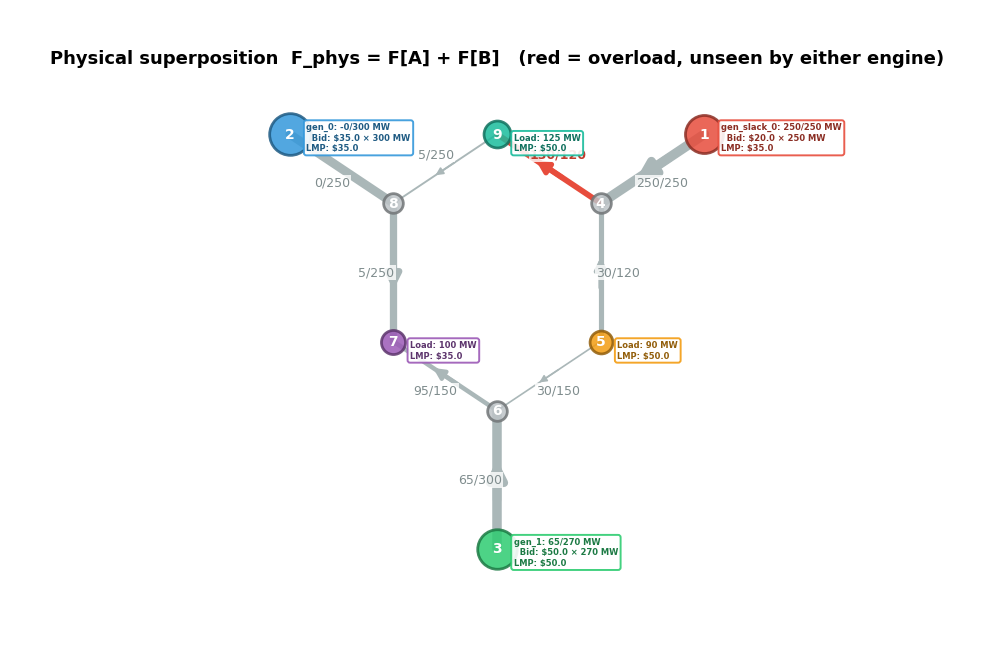

In [11]:
# Visual: physical superposition. Both engines' gens/loads on one map,
# line_flows = the PHYSICAL total. Width = slipperiness; red = genuinely
# overloaded (|F_phys| > rating), not merely at rating because a gen is maxed.
sup, dem = {}, {}
for eng, r in [(A, rA), (B, rB)]:
    s, d = to_supply_demand(eng, r); sup.update(s); dem.update(d)
colors = assign_bus_colors(pt.buses, sup, dem)
# host LMP for annotation (host = engine that owns the bus)
host_lmp = {}
for r, eng in [(rA, A), (rB, B)]:
    for b in eng.buses: host_lmp[b] = r.lmp[b]
phys = {l: pf.loc[l, 'F_phys'] for l in pt.lines}
overloaded = set(pf[pf.overload].index)
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=host_lmp, line_flows=phys,
    line_widths=susceptance_widths(pt), constrained_lines=overloaded, bus_coords=COORDS,
    title='Physical superposition  F_phys = F[A] + F[B]   (red = overload, unseen by either engine)',
)
plt.show()

**The point.** Engine A's LP and engine B's LP both returned *feasible,
within-limits* solutions. Yet `line_8` carries ~130 MW on a 120 MW wire because
each engine counted only its own injections (eq. 6) and treated the other's flow
as zero. This is the algebraic root of §4: $|F^M_m|\le\bar F_m$ for each $M$ does
**not** imply $|\sum_M F^M_m|\le\bar F_m$. No M2M / ADMM exchange is running here,
so nothing reconciles the two dispatches before the wire does.

## 4. Two engines — the price-taking export & the seam dual gap  (Part 2)

Same partition, but now look at the **trading layer**. From A's optimisation the
interchange is an *export decision*; from B's optimisation it is a **fixed,
price-insensitive injection** — a price taker that does not respond to B's LMP
(paper §2.3, §4.2: cross-engine contributions are "exogenous schedules, fixed in
advance and frozen during the clear").

Two consequences:

1. **The import does not respond to B's price.** Re-bid B's own generator and B's
   LMP moves, but the 150 MW keeps flowing in regardless.
2. **Seam dual gap** $\Delta\lambda_n=\lambda^B_n-\lambda^A_n\neq0$ at every bus
   (Prop. 1): the two engines value the *same* physical megawatt differently
   because each optimises over a different feasible set.

In [12]:
# -- EDIT -- re-bid generators inside each engine, watch the import stay fixed --
A_COSTS = {}                 # e.g. {'gen_0': 55.0}  raise A's mid unit
B_COSTS = {'gen_1': 50.0}    # e.g. {'gen_1': 15.0}  cheapen B's own gen
# -------------------------------------------------------------------------
for g, c in A_COSTS.items(): A.gens[g]['cost'] = c
for g, c in B_COSTS.items(): B.gens[g]['cost'] = c

rows = []
for E in [0.0, 75.0, 150.0]:
    rA = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -E})
    rB = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +E})
    rows.append({'import E (MW)': E,
                 'B own gen (MW)': round(sum(rB.dispatch.values()), 1),
                 'B served load (MW)': round(sum(B.loads.values()), 1),
                 'A energy $': round(rA.energy_price, 1),
                 'B energy $': round(rB.energy_price, 1),
                 'import price-taking?': 'yes -- fixed at E'})
print('B treats the import as exogenous: its own generation backs down 1-for-1 as E rises,')
print('the import never re-prices, and B energy price is set by B own marginal unit.')
print()
pd.DataFrame(rows)

B treats the import as exogenous: its own generation backs down 1-for-1 as E rises,

the import never re-prices, and B energy price is set by B own marginal unit.

,import E (MW),B own gen (MW),B served load (MW),A energy $,B energy $,import price-taking?
0,0.0,215.0,215.0,20.0,50.0,yes -- fixed at E
1,75.0,140.0,215.0,20.0,50.0,yes -- fixed at E
2,150.0,65.0,215.0,35.0,50.0,yes -- fixed at E


In [13]:
# Seam dual gap at every bus (Proposition 1 / eq. 25): three engines would give
# three LMPs per bus; with two engines there is one gap per bus.
rA = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -INTERCHANGE_MW})
rB = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +INTERCHANGE_MW})
gap = seam_dual_gap([rA, rB], pt.buses)
print('Each bus carries a host price and a counterparty price; the last column is the cross-engine basis.')
gap

Each bus carries a host price and a counterparty price; the last column is the cross-engine basis.

,λ[A - WEM],λ[B - Markets+],Δλ[A - WEM→B - Markets+]
bus,,,
1,35.0,50.0,15.0
2,35.0,50.0,15.0
3,35.0,50.0,15.0
4,35.0,50.0,15.0
5,35.0,50.0,15.0
6,35.0,50.0,15.0
7,35.0,50.0,15.0
8,35.0,50.0,15.0
9,35.0,50.0,15.0


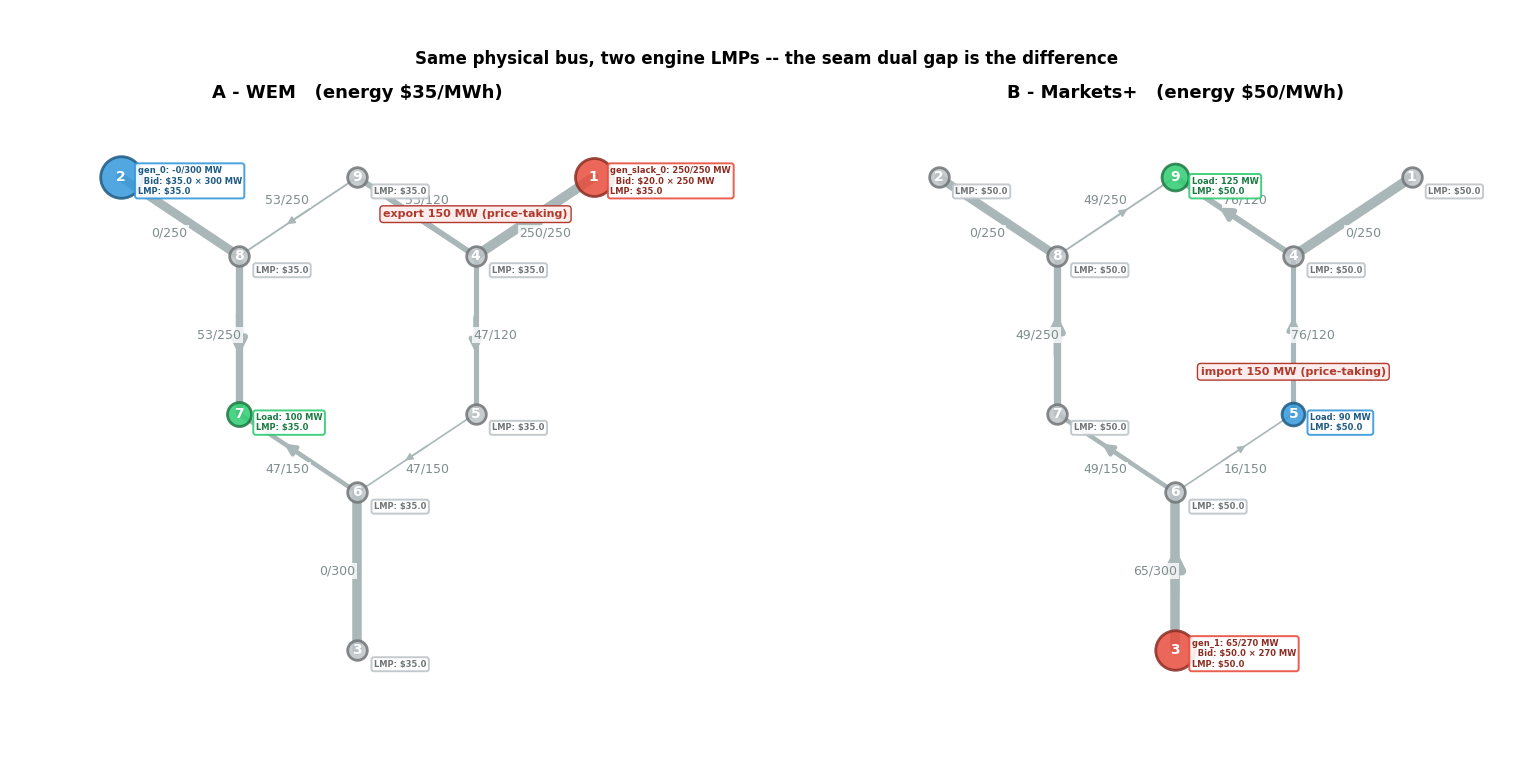

In [14]:
# The two engines side by side: same network, two different LMP fields.
# Width = slipperiness (identical on both, it is the shared physics);
# red = that engine's own binding lines (shadow price > 0).
wdt = susceptance_widths(pt)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, eng, r in [(axes[0], A, rA), (axes[1], B, rB)]:
    s, d = to_supply_demand(eng, r)
    exo_note = {EXPORT_BUS: -INTERCHANGE_MW} if eng is A else {IMPORT_BUS: +INTERCHANGE_MW}
    cols = assign_bus_colors(pt.buses, s, d)
    bind = {l for l, mu in r.line_dual.items() if abs(mu) > 1e-3}
    plot_network_topology(
        net, s, d, bus_colors=cols, bus_lmps=r.lmp,
        line_flows={l: r.flow_own[l] for l in pt.lines}, line_widths=wdt,
        constrained_lines=bind, bus_coords=COORDS, ax=ax,
        title=f'{eng.name}   (energy ${r.energy_price:.0f}/MWh)',
    )
    b = list(exo_note)[0]; mw = exo_note[b]
    label = ('export' if mw < 0 else 'import') + f' {abs(mw):.0f} MW (price-taking)'
    ax.annotate(label, COORDS[b], fontsize=8, fontweight='bold',
                color='#B03A2E', xytext=(0, 28), textcoords='offset points', ha='center',
                bbox=dict(boxstyle='round', fc='#FDEDEC', ec='#B03A2E'))
plt.suptitle('Same physical bus, two engine LMPs -- the seam dual gap is the difference',
             fontweight='bold')
plt.tight_layout(); plt.show()

**Settlement friction (§3.3).** A megawatt sold by A and bought by B settles
at A's interface price on one side and B's on the other; with $\Delta\lambda_n\neq0$
the two need not net to the transaction's physical value. The notebook shows the
two LMP fields; the paper's interface-pricing gap (eq. 28 — CAISO's generator-
weighted GAP-Tie vs SPP's load-weighted average) layers a *further* gap on top of
this bus-level one, even when the underlying $\lambda$'s agree.

## 5. Sandbox

One cell, every knob. Reassign buses to engines, change which constraints each
engine *activates* (`activated_lines` = the discretionary set $\mathcal M^M_{\text{act}}$),
move the interchange, re-bid units. Re-run to see prices and the overload move.

In [15]:
# -- EDIT -- free-form two-engine experiment ------------------------------
RATINGS        = {'line_1': 120.0, 'line_8': 120.0}
A_BUSES        = ['1', '2', '4', '7', '8']
B_BUSES        = ['3', '5', '6', '9']
A_ACTIVATED    = 'all'        # or a list e.g. ['line_1','line_0'] -> A ignores the rest
B_ACTIVATED    = 'all'
COSTS          = {}           # {'gen_1': 30.0}
LOADS_OVERRIDE = {}           # {'9': 160.0}
E_MW           = 150.0
TIE            = ('4', '5')   # (export_bus in A, import_bus in B)
# -------------------------------------------------------------------------
net = build_network(RATINGS); pt = compute_ptdf(net, slack_bus='1')
for b, v in LOADS_OVERRIDE.items(): LOADS[b] = v
A = make_engine('A', A_BUSES, activated=A_ACTIVATED)
B = make_engine('B', B_BUSES, activated=B_ACTIVATED)
for eng in (A, B):
    for g, c in COSTS.items():
        if g in eng.gens: eng.gens[g]['cost'] = c
rA = solve_engine_dispatch(pt, A, exo={TIE[0]: -E_MW})
rB = solve_engine_dispatch(pt, B, exo={TIE[1]: +E_MW})

print('A energy', round(rA.energy_price, 1), '| B energy', round(rB.energy_price, 1))
pf = physical_flows(pt, [rA, rB])
print('overloads (invisible to both engines):', pf[pf.overload].index.tolist() or 'none')
display(seam_dual_gap([rA, rB], pt.buses))
display(pf[['from', 'to', 'F[A]', 'F[B]', 'F_phys', 'rating', 'loading_%', 'overload']])

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


A energy

35.0

| B energy

50.0

overloads (invisible to both engines):

['line_8']

,λ[A],λ[B],Δλ[A→B]
bus,,,
1,35.0,50.0,15.0
2,35.0,50.0,15.0
3,35.0,50.0,15.0
4,35.0,50.0,15.0
5,35.0,50.0,15.0
6,35.0,50.0,15.0
7,35.0,50.0,15.0
8,35.0,50.0,15.0
9,35.0,50.0,15.0


,from,to,F[A],F[B],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,250.0,-0.0,250.0,250.0,100.0,False
line_1,4,5,46.7,-76.3,-29.6,120.0,25.0,False
line_2,5,6,46.7,-16.3,30.4,150.0,20.0,False
line_3,3,6,0.0,65.0,65.0,300.0,22.0,False
line_4,6,7,46.7,48.7,95.4,150.0,64.0,False
line_5,7,8,-53.3,48.7,-4.6,250.0,2.0,False
line_6,8,2,0.0,0.0,0.0,250.0,0.0,False
line_7,8,9,-53.3,48.7,-4.6,250.0,2.0,False
line_8,9,4,-53.3,-76.3,-129.6,120.0,108.0,True


---
*Computation: [`seams_engine.py`](seams_engine.py) (PTDF DC-OPF, dual-derived LMPs).
Network: [`ieee9_network.py`](ieee9_network.py). Plots: [`nodal_plot.py`](nodal_plot.py).
Validated against the Egret SCED LMPs in `inspect_sced_results.ipynb`.*